### Linear Regression in R

Steps:

  * Carry out the experiment of gathering a sample of observed values of height and corresponding weight.
  * Create a relationship model using the **lm()** functions in R.
  * Find the coefficients from the model created and create the mathematical equation using these
  * Get a summary of the relationship model to know the average error in prediction. Also called residuals.
  * To predict the output of given input, use the **predict()** function in R.


In [ ]:
# The predictor vector.
x <- c(151, 174, 138, 186, 128, 136, 179, 163, 152, 131)
# The resposne vector.
y <- c(63, 81, 56, 91, 47, 57, 76, 72, 62, 48)

# y = b1 x + b0
# Apply the lm() function.
relation <- lm(y~x)
print(relation)



Call:
lm(formula = y ~ x)

Coefficients:
(Intercept)            x  
   -38.4551       0.6746  



y = 0.6746 x -38.4551

In [ ]:
# predict
# Find weight of a person with height 170.
a <- data.frame(x = 170)
result <-  predict(relation,a)
print(result)

       1 
76.22869 


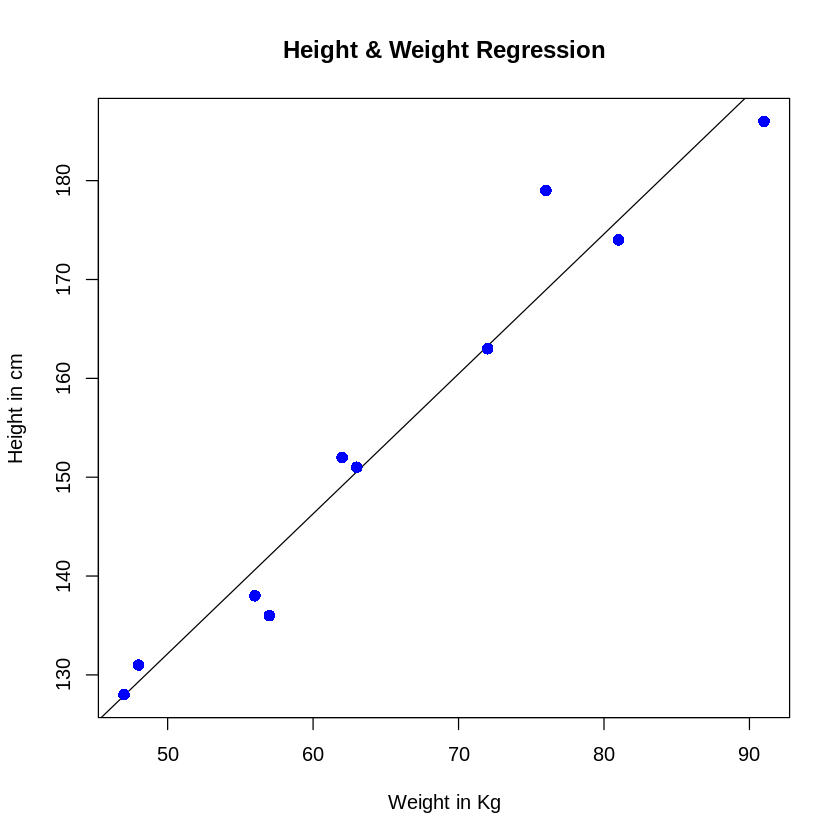

In [ ]:
# Give the chart file a name.
#png(file = "linearregression.png")

# Plot the chart.
plot(y,x,col = "blue",main = "Height & Weight Regression",
abline(lm(x~y)),cex = 1.3,pch = 16,xlab = "Weight in Kg",ylab = "Height in cm")



## Example


In [ ]:
# Create the data frame
data <- data.frame(
Years_Exp = c(1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7),
Salary = c(39343.00, 46205.00, 37731.00, 43525.00,
			39891.00, 56642.00, 60150.00, 54445.00, 64445.00, 57189.00)
)
head(data)

,Years_Exp,Salary
,<dbl>,<dbl>
1,1.1,39343
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.9,56642


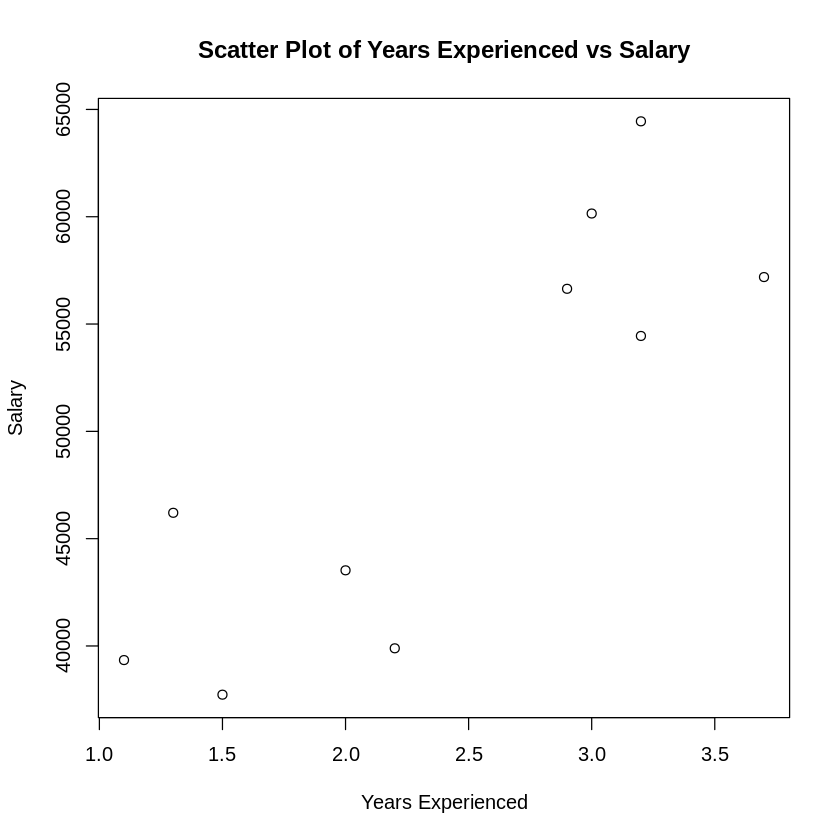

In [ ]:
# Create the scatter plot
plot(data$Years_Exp, data$Salary,
	xlab = "Years Experienced",
	ylab = "Salary",
	main = "Scatter Plot of Years Experienced vs Salary")


In [ ]:
# linear model
install.packages('caTools')
library(caTools)
split = sample.split(data$Salary, SplitRatio = 0.7)
trainingset = subset(data, split == TRUE)
testset = subset(data, split == FALSE)

# Fitting Simple Linear Regression to the Training set
lm.r= lm(formula = Salary ~ Years_Exp,
		data = trainingset)
coef(lm.r)

# Predicting the Test set results
ypred = predict(lm.r, newdata = testset)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘bitops’




(Intercept)   Years_Exp 
  30108.730    8394.432

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



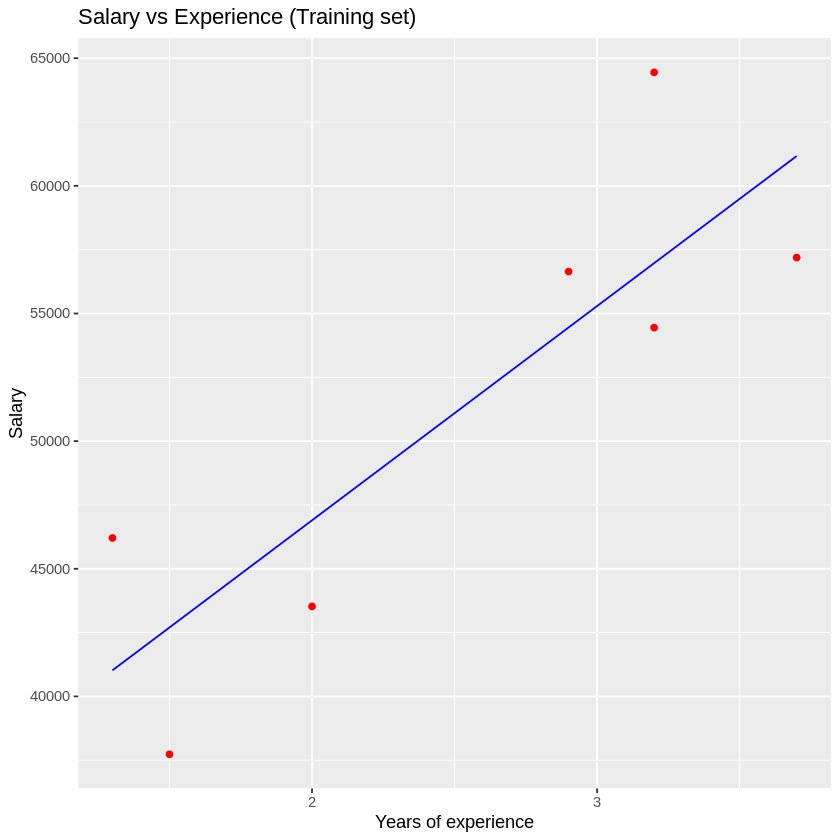

In [ ]:
# Visualising the Training set results
install.packages('ggplot2')
library(ggplot2)
ggplot() + geom_point(aes(x = trainingset$Years_Ex,
						y = trainingset$Salary), colour = 'red') +
geom_line(aes(x = trainingset$Years_Ex,
				y = predict(lm.r, newdata = trainingset)), colour = 'blue') +

ggtitle('Salary vs Experience (Training set)') +
xlab('Years of experience') +
ylab('Salary')


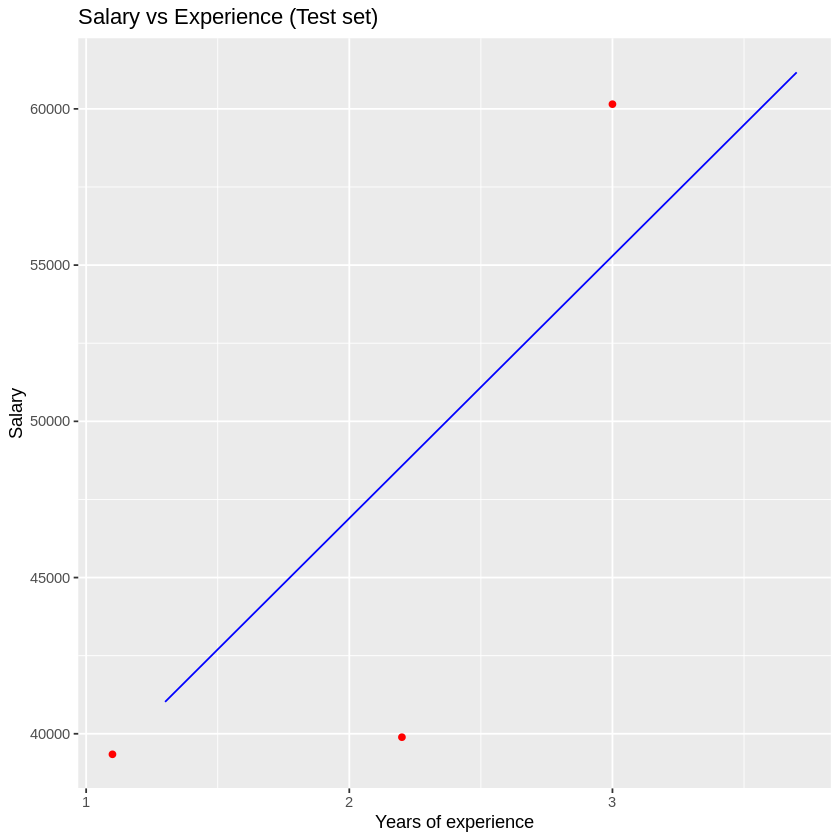

In [ ]:
# test set
# Visualising the Test set results
ggplot() +
geom_point(aes(x = testset$Years_Exp, y = testset$Salary),
			colour = 'red') +
geom_line(aes(x = trainingset$Years_Exp,
				y = predict(lm.r, newdata = trainingset)),
			colour = 'blue') +
ggtitle('Salary vs Experience (Test set)') +
xlab('Years of experience') +
ylab('Salary')
